In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 1. Load Dataset

In [41]:
df = pd.read_csv("../processing/data/final_dataset.csv", sep =",")

df.head()

,url,job_title,tech_stack,language_req,is_manager,work_method,contract_type,salary_min,salary_max,exp_years,location,job_level,source,company_name,education_level,is_shift_work
0,https://www.topcv.vn/viec-lam/business-analyst...,Business Analyst,Visio,1,0,Onsite,Full-time,12.0,15.0,1.0,Hà Nội,2,topcv,INVIV CLOUD TECHNOLOGY JOINT STOCK COMPANY,Bachelor,0
1,https://www.topcv.vn/viec-lam/technical-leader...,Technical Leader (PHP/Laravel),"JavaScript, GitHub, REST API, Elasticsearch, I...",0,1,Onsite,Full-time,NaN,NaN,5.0,Hà Nội,3,topcv,CÔNG TY CỔ PHẦN VIETEZ VIỆT NAM,Bachelor,0
2,https://www.topcv.vn/viec-lam/business-analyst...,Business Analyst (Product),"Adobe Illustrator, Visio",1,0,Onsite,Full-time,NaN,NaN,2.0,Hà Nội,2,topcv,VIETTEL IDC,Bachelor,0
3,https://www.topcv.vn/viec-lam/frontend-develop...,Frontend Developer (Web/App IRUKA),"HTML, React, JavaScript, Next.js, Zustand, CSS...",1,0,Onsite,Full-time,NaN,NaN,2.0,Hà Nội,2,topcv,CÔNG TY TNHH THƯƠNG MẠI DỊCH VỤ LIFESTYLE VIỆT...,Bachelor,0
4,https://www.topcv.vn/viec-lam/business-analyst...,Business Analyst (Level Middle Trở Lên),NaN,1,0,Onsite,Full-time,20.0,50.0,3.0,Hà Nội,2,topcv,TỔNG CÔNG TY CỔ PHẦN BƯU CHÍNH VIETTEL,Bachelor,0


In [92]:
df.columns

Index(['url', 'job_title', 'tech_stack', 'language_req', 'is_manager',
       'work_method', 'contract_type', 'salary_min', 'salary_max', 'exp_years',
       'location', 'job_level', 'source', 'company_name', 'education_level',
       'is_shift_work', 'salary_range'],
      dtype='str')

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5661 entries, 0 to 5660
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              5661 non-null   str    
 1   job_title        5661 non-null   str    
 2   tech_stack       4671 non-null   str    
 3   language_req     5661 non-null   int64  
 4   is_manager       5661 non-null   int64  
 5   work_method      5661 non-null   str    
 6   contract_type    4267 non-null   str    
 7   salary_min       2140 non-null   float64
 8   salary_max       2353 non-null   float64
 9   exp_years        5661 non-null   float64
 10  location         5661 non-null   str    
 11  job_level        5661 non-null   int64  
 12  source           5661 non-null   str    
 13  company_name     5614 non-null   str    
 14  education_level  3405 non-null   str    
 15  is_shift_work    5661 non-null   int64  
 16  salary_range     2094 non-null   str    
dtypes: float64(3), int64(4), 

## 2. Dataset Overview

In [94]:
print("Dataset shape:", df.shape)

Dataset shape: (5661, 17)


In [43]:
df[['salary_min','salary_max']].describe()

,salary_min,salary_max
count,2140.000000,2353.000000
mean,18.973640,31.433923
std,19.828593,30.246911
min,0.250000,0.380000
25%,10.000000,15.000000
50%,15.000000,25.000000
75%,25.000000,40.000000
max,500.000000,800.000000


In [95]:
for col in ['salary_min','salary_max']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print("Column:", col)
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))
    print("----------")

Column: salary_min
Lower bound: -12.5
Upper bound: 47.5
Number of outliers: 101
----------
Column: salary_max
Lower bound: -22.5
Upper bound: 77.5
Number of outliers: 75
----------


In [79]:
outliers = df[(df['salary_max'] > upper) | (df['salary_max'] < lower)]

outliers[['url','job_title','company_name','salary_min','salary_max']].head(20)

,url,job_title,company_name,salary_min,salary_max
87,https://www.topcv.vn/viec-lam/senior-devops-si...,Senior DevOps / Site Reliability Engineer (SRE...,CÔNG TY TNHH BELLE ASIA,NaN,100.0
107,https://www.topcv.vn/viec-lam/lead-full-stack-...,Lead Full-Stack Developer – Up To 90M+,CÔNG TY TNHH MONIVA VIETNAM,50.0,90.0
125,https://www.topcv.vn/viec-lam/lead-mobile-deve...,Lead Mobile Developer (High Salary 60–90M),CÔNG TY TNHH MONIVA VIETNAM,60.0,90.0
577,https://www.topcv.vn/viec-lam/jp-223-ky-su-lap...,(JP 223) Kỹ Sư Lập Trình Vận Hành Máy Gia Công...,CTY TNHH R TECHNO VIỆT NAM,65.2,81.5
819,https://careerviet.vn/vi/tim-viec-lam/solution...,Solution Architect,CÔNG TY CỔ PHẦN TẬP ĐOÀN MEEY LAND,40.0,80.0
937,https://careerviet.vn/vi/tim-viec-lam/giam-doc...,Giám đốc Sản phẩm (Product Director),CÔNG TY CỔ PHẦN TẬP ĐOÀN MEEY LAND,60.0,80.0
1310,https://www.topcv.vn/viec-lam/system-engineer/...,System Engineer,CÔNG TY CỔ PHẦN CÔNG NGHỆ SMILE,60.0,105.0
1322,https://www.topcv.vn/viec-lam/giam-doc-cong-ng...,Giám Đốc Công Nghệ Thông Tin,CÔNG TY CỔ PHẦN IN VÀ BAO BÌ GOLDSUN,60.0,80.0
1561,https://www.topcv.vn/viec-lam/bridge-software-...,Bridge Software Engineer,CÔNG TY CỔ PHẦN BRAVESOFT VIỆT NAM,30.0,80.0
1644,https://www.topcv.vn/viec-lam/enterprise-archi...,Enterprise Architects,CÔNG TY CỔ PHẦN CÔNG NGHỆ ALPHAWAY,60.0,100.0


In [80]:
outliers.shape[0]

75

In [97]:
outlier_ratio = len(outliers) / len(df)

print("Outlier ratio:", round(outlier_ratio * 100, 2), "%")

Outlier ratio: 1.32 %


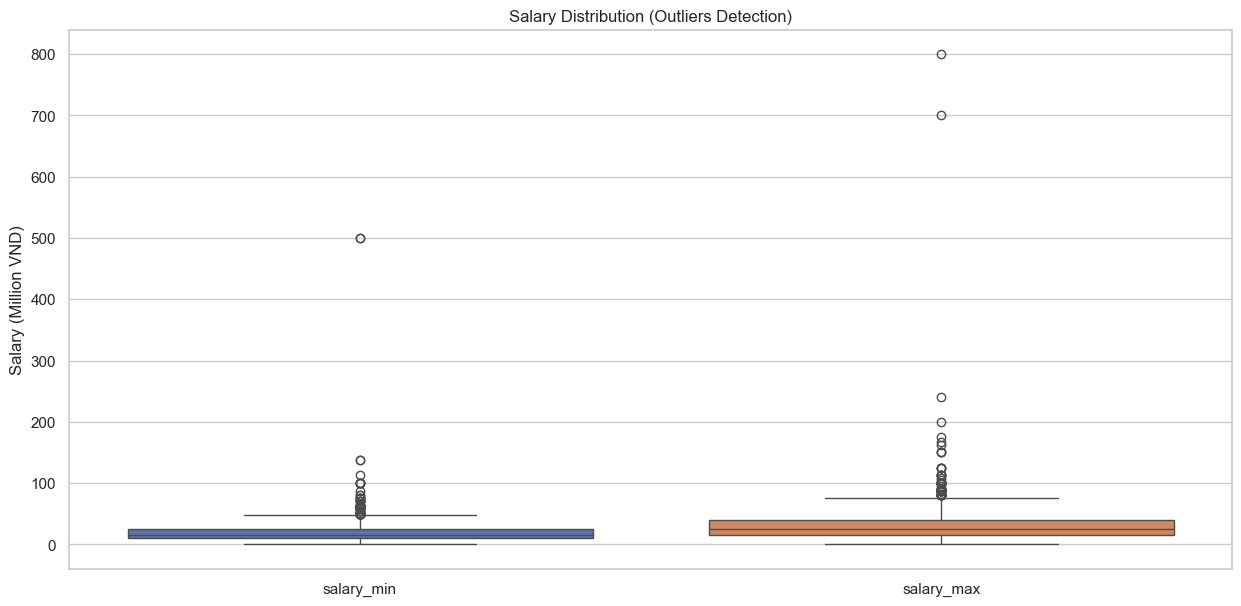

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

sns.boxplot(data=df[['salary_min','salary_max']])

plt.title("Salary Distribution (Outliers Detection)")
plt.ylabel("Salary (Million VND)")

plt.show()

In [83]:
df.sort_values('salary_max', ascending=False)[
    ['url','job_title','salary_min','salary_max']
].head(10)

,url,job_title,salary_min,salary_max
3668,https://glints.com/vn/opportunities/jobs/f31d6...,Frontend Game Developer,500.0,800.00
4486,https://www.vietnamworks.com/kien-truc-su-phan...,Kiến Trúc Sư Phần Mềm (SA),500.0,700.00
3724,https://glints.com/vn/opportunities/jobs/75f27...,Cán bộ kỹ thuật hiện trường,18.0,240.00
3206,https://glints.com/vn/opportunities/jobs/6ee34...,Back-end Developer,13.0,200.00
4072,https://www.vietnamworks.com/principle-full-st...,Principle Full-Stack Engineer (R&D),25.0,175.00
4913,https://www.vietnamworks.com/giam-djoc-kinh-do...,Giám Đốc Kinh Doanh Dịch Vụ Outsourcing CNTT Q...,NaN,166.67
5589,https://itviec.com/it-jobs/staff-frontend-engi...,Staff-level Frontend Engineer TypeScript/JavaS...,112.5,162.50
3933,https://www.vietnamworks.com/ha-noi-senior-exp...,[Hà Nội] Senior / Expert Data Governance,137.5,150.00
3932,https://www.vietnamworks.com/ha-noi-data-produ...,[Hà Nội] Data Product Manager (Data Platform),137.5,150.00
4447,https://www.vietnamworks.com/senior-full-stack...,Senior Full-Stack Web and AI Developer,37.5,150.00


In [86]:
missing_values = df.isna().sum().sort_values(ascending=False)

missing_values

salary_range       3567
salary_min         3521
salary_max         3308
education_level    2256
contract_type      1394
tech_stack          990
company_name         47
url                   0
is_manager            0
work_method           0
job_title             0
language_req          0
exp_years             0
source                0
job_level             0
location              0
is_shift_work         0
dtype: int64

In [96]:
missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)

missing_rate = missing_rate.round(2).astype(str) + '%'

print(missing_rate)

salary_range       63.01%
salary_min          62.2%
salary_max         58.43%
education_level    39.85%
contract_type      24.62%
tech_stack         17.49%
company_name        0.83%
url                  0.0%
is_manager           0.0%
work_method          0.0%
job_title            0.0%
language_req         0.0%
exp_years            0.0%
source               0.0%
job_level            0.0%
location             0.0%
is_shift_work        0.0%
dtype: str


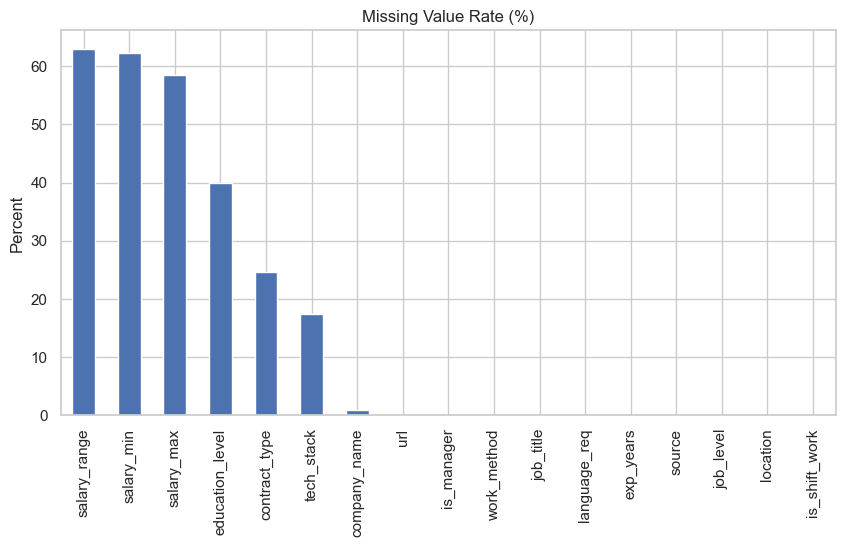

In [88]:
plt.figure(figsize=(10,5))
missing_rate.plot(kind="bar")
plt.title("Missing Value Rate (%)")
plt.ylabel("Percent")
plt.show()

In [89]:
invalid_salary = df[df['salary_min'] > df['salary_max']]
print("Invalid salary rows:", len(invalid_salary))

Invalid salary rows: 0


In [90]:
print("Missing salary_min:", df['salary_min'].isna().sum())
print("Missing salary_max:", df['salary_max'].isna().sum())


print("salary_min > salary_max:", len(df[df['salary_min'] > df['salary_max']]))

Missing salary_min: 3521
Missing salary_max: 3308
salary_min > salary_max: 0
